In [5]:
import pandas as pd
import geopandas as gpd
from shapely import wkt

In [8]:
import pandas as pd
import geopandas as gpd

# 1. Membaca data mentah menggunakan Pandas
print("1. Membaca file parquet mentah (667 MB)...")
df_raw = pd.read_parquet('../data/raw/groundsource_2026.parquet')

# 2. Mengubah data biner (WKB) menjadi objek spasial GeoPandas
print("2. Mengonversi format biner WKB menjadi objek geometri...")
df_raw['geometry'] = gpd.GeoSeries.from_wkb(df_raw['geometry'])

# 3. Menjadikan GeoDataFrame dengan sistem koordinat bumi standar (EPSG:4326)
gdf_global = gpd.GeoDataFrame(df_raw, geometry='geometry', crs="EPSG:4326")

# 4. Memuat peta batas negara (MENGGUNAKAN URL LANGSUNG UNTUK GEOPANDAS 1.0+)
print("3. Memuat batas peta negara dari internet...")
url_peta_dunia = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"
world = gpd.read_file(url_peta_dunia)

# 5. Mengambil poligon peta khusus Indonesia
indonesia_map = world[world['name'] == 'Indonesia']

# 6. SPATIAL JOIN: Memfilter kejadian banjir yang berada di dalam peta Indonesia
print("4. Memfilter kejadian banjir khusus di wilayah Indonesia (proses ini mungkin butuh beberapa menit)...")
gdf_indo = gpd.sjoin(gdf_global, indonesia_map, predicate='intersects')

# 7. Membuang kolom tambahan sisa dari peta dunia, sisakan 5 kolom utama
kolom_penting = ['uuid', 'area_km2', 'geometry', 'start_date', 'end_date']
gdf_indo_final = gdf_indo[kolom_penting]

# ========================================================
# 8. DATA EXAMINATION (Sesuai Draf Laporan Langkah 2)
# ========================================================
print("\n" + "="*40)
print("HASIL DATA EXAMINATION (INDONESIA)")
print("="*40)

# A. Tinjauan Struktur
print(f"\n[A] Dimensi Data (Baris, Kolom): {gdf_indo_final.shape}")

# B. Informasi Tipe Data & Kelengkapan
print("\n[B] Informasi Tipe Data:")
gdf_indo_final.info()

print("\n[C] Jumlah Missing Values tiap kolom:")
print(gdf_indo_final.isnull().sum())

# C. Identifikasi Duplikasi
jumlah_duplikat = gdf_indo_final.duplicated(subset=['start_date', 'end_date', 'area_km2']).sum()
print(f"\n[D] Potensi jumlah baris duplikat (berdasarkan kesamaan waktu & luasan area): {jumlah_duplikat}")

# ========================================================
# 9. Menyimpan data yang sudah difilter ke format parquet lagi
# ========================================================
print("\n5. Menyimpan data khusus Indonesia ke folder processed...")
gdf_indo_final.to_parquet('../data/processed/groundsource_indonesia.parquet', index=False)
print("Semua proses selesai dengan sukses!")

1. Membaca file parquet mentah (667 MB)...
2. Mengonversi format biner WKB menjadi objek geometri...
3. Memuat batas peta negara dari internet...
4. Memfilter kejadian banjir khusus di wilayah Indonesia (proses ini mungkin butuh beberapa menit)...

HASIL DATA EXAMINATION (INDONESIA)

[A] Dimensi Data (Baris, Kolom): (310731, 5)

[B] Informasi Tipe Data:
<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 310731 entries, 36 to 2752389
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   uuid        310731 non-null  object  
 1   area_km2    310731 non-null  float64 
 2   geometry    310731 non-null  geometry
 3   start_date  310731 non-null  object  
 4   end_date    310731 non-null  object  
dtypes: float64(1), geometry(1), object(3)
memory usage: 14.2+ MB

[C] Jumlah Missing Values tiap kolom:
uuid          0
area_km2      0
geometry      0
start_date    0
end_date      0
dtype: int64

[D] Potensi jumlah baris dupl

In [9]:
# ========================================================
# 10. DATA CLEANING & QUALITY IMPROVEMENT
# ========================================================
print("Memulai proses pembersihan data...")

# A. Menghapus Duplikasi
sebelum_drop = len(gdf_indo_final)
# Menghapus duplikat berdasarkan waktu dan ukuran area yang persis sama
gdf_clean = gdf_indo_final.drop_duplicates(subset=['start_date', 'end_date', 'area_km2']).copy()
sesudah_drop = len(gdf_clean)
print(f"-> Menghapus duplikat: Berkurang dari {sebelum_drop} menjadi {sesudah_drop} baris.")

# B. Memperbaiki Tipe Data Waktu (Temporal)
# Mengubah teks menjadi format datetime agar tahunnya bisa diambil nanti
gdf_clean['start_date'] = pd.to_datetime(gdf_clean['start_date'])
gdf_clean['end_date'] = pd.to_datetime(gdf_clean['end_date'])
print("-> Konversi kolom waktu menjadi tipe datetime berhasil.")

# C. Menangani Missing Values (Bila ada)
# Menghapus baris yang tanggal mulai atau areanya kosong
gdf_clean = gdf_clean.dropna(subset=['start_date', 'area_km2', 'geometry'])
print(f"-> Baris final setelah membersihkan missing values: {len(gdf_clean)} baris.")

# D. Menyimpan Data Bersih
gdf_clean.to_parquet('../data/processed/groundsource_indonesia_clean.parquet', index=False)
print("\nData bersih berhasil disimpan ke 'groundsource_indonesia_clean.parquet'!")

Memulai proses pembersihan data...
-> Menghapus duplikat: Berkurang dari 310731 menjadi 310697 baris.
-> Konversi kolom waktu menjadi tipe datetime berhasil.
-> Baris final setelah membersihkan missing values: 310697 baris.

Data bersih berhasil disimpan ke 'groundsource_indonesia_clean.parquet'!


In [10]:
# ========================================================
# 11. DATA TRANSFORMATION & AGGREGATION
# ========================================================
print("Melakukan transformasi data...")

# A. Mengekstrak Tahun dari start_date
gdf_clean['year'] = gdf_clean['start_date'].dt.year

# B. Agregasi Data: Menghitung Frekuensi dan Total Area per Tahun
# Kita kelompokkan berdasarkan 'year'
df_trend = gdf_clean.groupby('year').agg(
    frekuensi_banjir=('uuid', 'count'),       # Menghitung jumlah kejadian
    total_area_km2=('area_km2', 'sum')        # Menjumlahkan luas area terdampak
).reset_index()

# Mengurutkan berdasarkan tahun agar rapi
df_trend = df_trend.sort_values('year')

# Menampilkan 5 tahun pertama dan 5 tahun terakhir sebagai bukti
print("\n[Hasil Transformasi] Tren Banjir 2000 - 2026:")
print(df_trend.head())
print("...")
print(df_trend.tail())

# C. Menyimpan Dataset Final (Inilah data yang akan divisualisasikan!)
df_trend.to_csv('../data/processed/trend_banjir_indonesia_2000_2026.csv', index=False)
print("\nDataset FINAL berhasil disimpan ke format CSV ('trend_banjir_indonesia_2000_2026.csv')!")

Melakukan transformasi data...

[Hasil Transformasi] Tren Banjir 2000 - 2026:
   year  frekuensi_banjir  total_area_km2
0  2000                 2     2810.673723
1  2001                 2      422.438832
2  2002                26     8314.873103
3  2003                21     2020.188209
4  2004                 8     1549.349115
...
    year  frekuensi_banjir  total_area_km2
22  2022             36675    4.259661e+06
23  2023             25850    3.184410e+06
24  2024             43075    5.663502e+06
25  2025             59246    6.494240e+06
26  2026             10934    9.272079e+05

Dataset FINAL berhasil disimpan ke format CSV ('trend_banjir_indonesia_2000_2026.csv')!


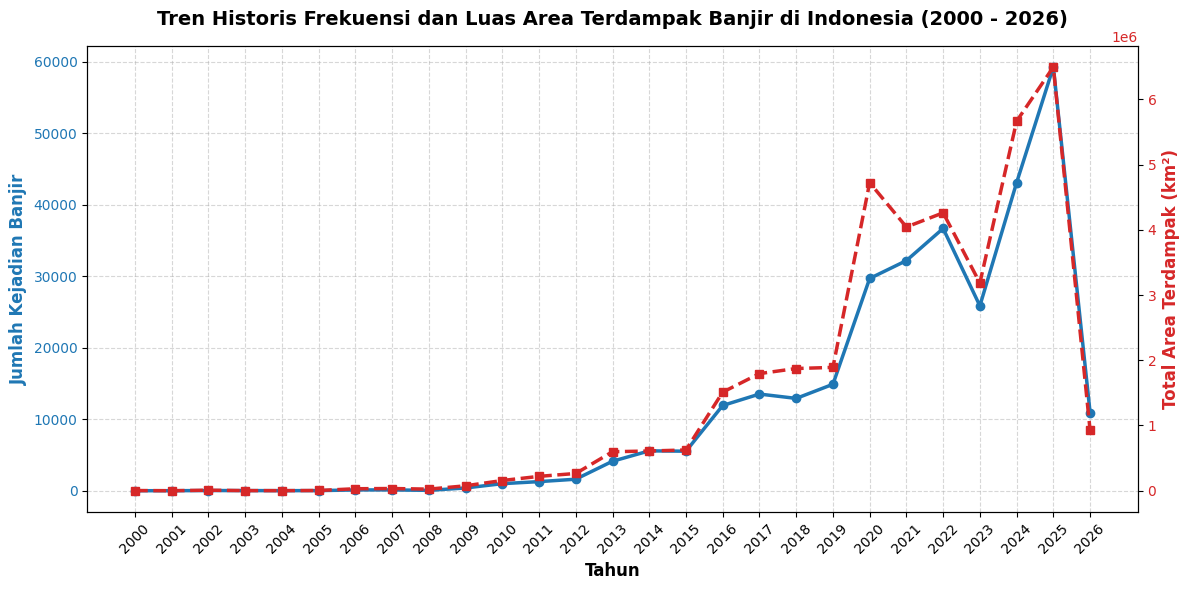

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Membaca data trend final
df_trend = pd.read_csv('../data/processed/trend_banjir_indonesia_2000_2026.csv')

# 2. Membuat kanvas (figure) dan sumbu utama (ax1)
fig, ax1 = plt.subplots(figsize=(12, 6))

# ==========================================
# PLOT 1: Frekuensi Banjir (Garis Biru, Sumbu Kiri)
# ==========================================
color1 = '#1f77b4' # Biru
ax1.set_xlabel('Tahun', fontweight='bold', fontsize=12)
ax1.set_ylabel('Jumlah Kejadian Banjir', color=color1, fontweight='bold', fontsize=12)
ax1.plot(df_trend['year'], df_trend['frekuensi_banjir'], color=color1, marker='o', linewidth=2.5)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(df_trend['year']) # Menampilkan semua tahun di sumbu X
ax1.tick_params(axis='x', rotation=45) # Memiringkan teks tahun agar tidak bertabrakan
ax1.grid(True, linestyle='--', alpha=0.5)

# ==========================================
# PLOT 2: Area Terdampak (Garis Merah, Sumbu Kanan)
# ==========================================
ax2 = ax1.twinx()  # Membuat sumbu Y kedua yang berbagi sumbu X yang sama
color2 = '#d62728' # Merah
ax2.set_ylabel('Total Area Terdampak (km²)', color=color2, fontweight='bold', fontsize=12)
ax2.plot(df_trend['year'], df_trend['total_area_km2'], color=color2, marker='s', linestyle='--', linewidth=2.5)
ax2.tick_params(axis='y', labelcolor=color2)

# ==========================================
# FINALISASI TAMPILAN
# ==========================================
plt.title('Tren Historis Frekuensi dan Luas Area Terdampak Banjir di Indonesia (2000 - 2026)', 
          fontsize=14, fontweight='bold', pad=15)

fig.tight_layout() # Merapikan layout agar tidak ada yang terpotong

# Menampilkan grafik
plt.show()

1. Membaca data banjir yang sudah dibersihkan...
2. Mengunduh peta batas provinsi Indonesia...
3. Memetakan titik banjir ke masing-masing provinsi (tunggu sebentar)...

[HASIL] Top 5 Provinsi paling terdampak: ['JAWA BARAT', 'JAWA TIMUR', 'JAWA TENGAH', 'DI. ACEH', 'DKI JAKARTA']


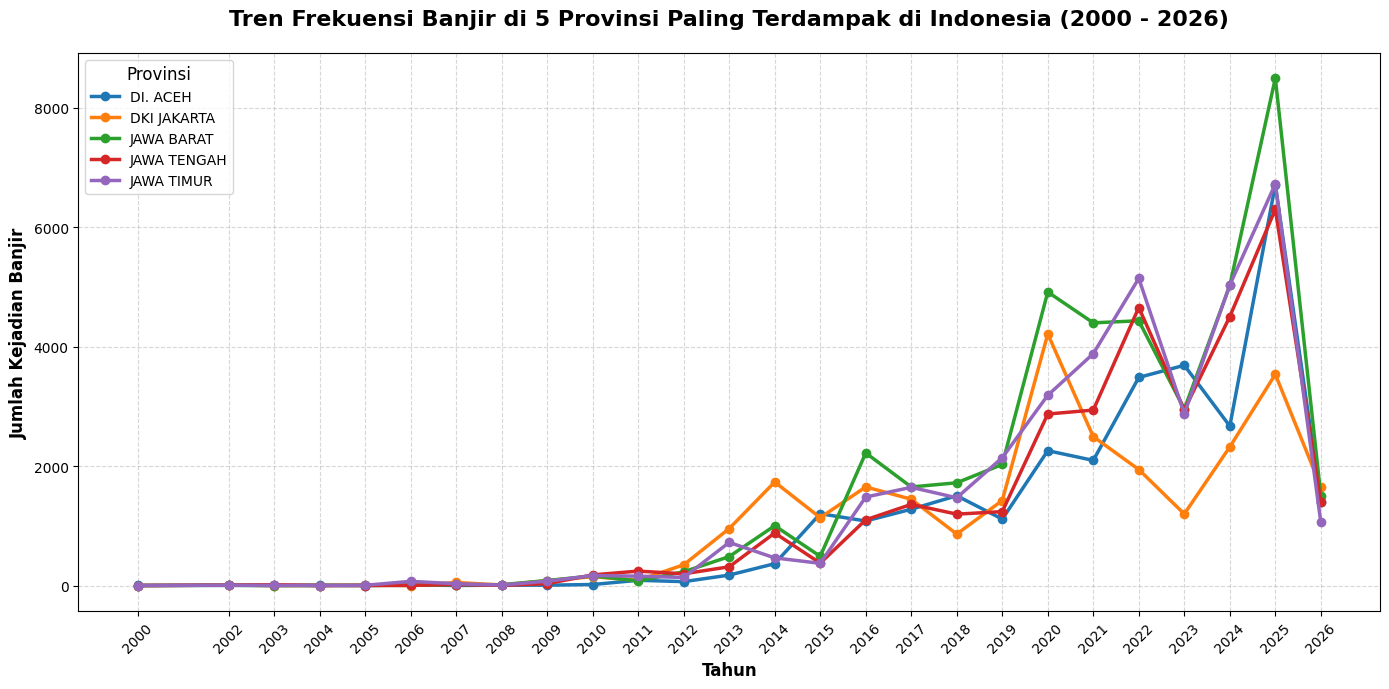

In [13]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Membaca data bersih yang sudah kita simpan sebelumnya
print("1. Membaca data banjir yang sudah dibersihkan...")
gdf_clean = gpd.read_parquet('../data/processed/groundsource_indonesia_clean.parquet')

# 2. Mengunduh Peta Provinsi Indonesia (URL Baru yang Valid)
print("2. Mengunduh peta batas provinsi Indonesia...")
url_prov = "https://raw.githubusercontent.com/superpikar/indonesia-geojson/master/indonesia-province-simple.json"
prov_map = gpd.read_file(url_prov)

# Pastikan sistem koordinatnya (CRS) sama sebelum digabungkan
if gdf_clean.crs != prov_map.crs:
    prov_map = prov_map.to_crs(gdf_clean.crs)

# 3. SPATIAL JOIN: Mencocokkan titik koordinat banjir dengan poligon provinsi
print("3. Memetakan titik banjir ke masing-masing provinsi (tunggu sebentar)...")
gdf_prov = gpd.sjoin(gdf_clean, prov_map, predicate='intersects')

# 4. Mencari 5 Provinsi paling terdampak (berdasarkan frekuensi tertinggi)
# Di URL baru ini, nama kolom untuk provinsi adalah 'Propinsi'
col_prov = 'Propinsi' 
top_5_prov = gdf_prov[col_prov].value_counts().nlargest(5).index.tolist()
print(f"\n[HASIL] Top 5 Provinsi paling terdampak: {top_5_prov}")

# 5. Memfilter data hanya untuk Top 5 Provinsi dan ekstrak tahun
df_top5 = gdf_prov[gdf_prov[col_prov].isin(top_5_prov)].copy()
df_top5['year'] = df_top5['start_date'].dt.year

# 6. Agregasi Data: Menghitung frekuensi per tahun untuk masing-masing provinsi
df_trend_prov = df_top5.groupby(['year', col_prov]).size().reset_index(name='frekuensi')

# Melakukan Pivot tabel agar mudah dibuat grafiknya
df_pivot = df_trend_prov.pivot(index='year', columns=col_prov, values='frekuensi').fillna(0)

# ==========================================
# 7. VISUALISASI DATA (MULTIPLE LINE CHART)
# ==========================================
fig, ax = plt.subplots(figsize=(14, 7))

# Plot garis untuk setiap provinsi
for prov in df_pivot.columns:
    ax.plot(df_pivot.index, df_pivot[prov], marker='o', linewidth=2.5, label=prov)

# Pengaturan Judul dan Label
ax.set_title('Tren Frekuensi Banjir di 5 Provinsi Paling Terdampak di Indonesia (2000 - 2026)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Tahun', fontsize=12, fontweight='bold')
ax.set_ylabel('Jumlah Kejadian Banjir', fontsize=12, fontweight='bold')

# Pengaturan Sumbu X dan Grid
ax.set_xticks(df_pivot.index)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, linestyle='--', alpha=0.5)

# Menampilkan Legenda (Daftar Provinsi)
ax.legend(title='Provinsi', title_fontsize=12, fontsize=10, loc='upper left')

fig.tight_layout()
plt.show()

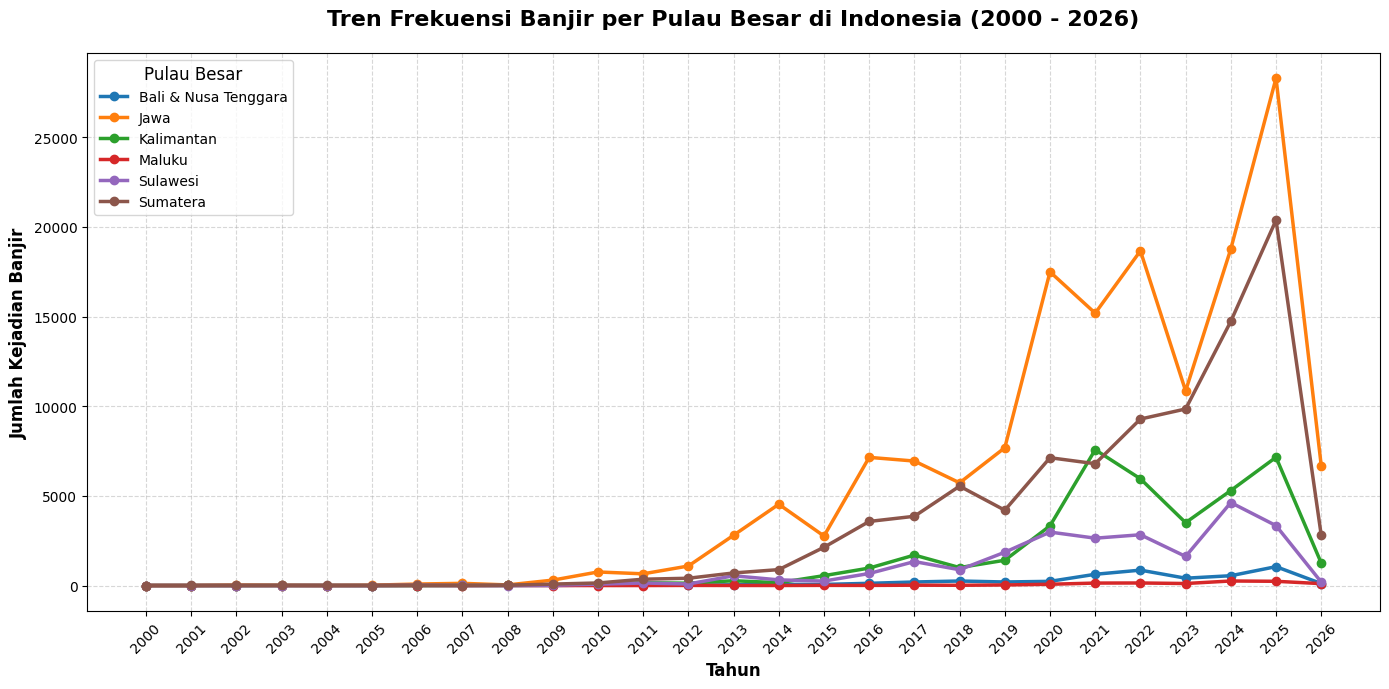

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Membuat fungsi pemetaan dari Provinsi ke Pulau Besar
# Menggunakan deteksi kata kunci agar kebal terhadap perbedaan huruf besar/kecil
def kelompokkan_pulau(provinsi):
    prov = str(provinsi).lower()
    if any(x in prov for x in ['aceh', 'sumatera', 'riau', 'jambi', 'bengkulu', 'lampung', 'bangka']):
        return 'Sumatera'
    elif any(x in prov for x in ['jakarta', 'jawa', 'banten', 'yogyakarta']):
        return 'Jawa'
    elif 'kalimantan' in prov:
        return 'Kalimantan'
    elif any(x in prov for x in ['sulawesi', 'gorontalo']):
        return 'Sulawesi'
    elif any(x in prov for x in ['bali', 'nusa tenggara', 'ntb', 'ntt']):
        return 'Bali & Nusa Tenggara'
    elif 'maluku' in prov:
        return 'Maluku'
    elif 'papua' in prov:
        return 'Papua'
    else:
        return 'Lainnya'

# 2. Menerapkan pemetaan ke dataset yang sudah di-join dengan peta (gdf_prov)
# Pastikan Anda menjalankan ini di notebook yang sama setelah kode provinsi sebelumnya sukses
gdf_prov['Pulau'] = gdf_prov['Propinsi'].apply(kelompokkan_pulau)

# 3. Ekstrak tahun (berjaga-jaga jika kolom year belum ada)
if 'year' not in gdf_prov.columns:
    gdf_prov['year'] = gdf_prov['start_date'].dt.year

# 4. Agregasi Data: Menghitung frekuensi per tahun untuk masing-masing Pulau Besar
df_trend_pulau = gdf_prov.groupby(['year', 'Pulau']).size().reset_index(name='frekuensi')

# 5. Pivot tabel agar mudah dibuat grafiknya
df_pivot_pulau = df_trend_pulau.pivot(index='year', columns='Pulau', values='frekuensi').fillna(0)

# ==========================================
# 6. VISUALISASI DATA (MULTIPLE LINE CHART)
# ==========================================
fig, ax = plt.subplots(figsize=(14, 7))

# Plot garis untuk setiap pulau besar
for pulau in df_pivot_pulau.columns:
    if pulau != 'Lainnya':  # Mengabaikan kategori 'Lainnya' jika ada
        ax.plot(df_pivot_pulau.index, df_pivot_pulau[pulau], marker='o', linewidth=2.5, label=pulau)

# Pengaturan Judul dan Label
ax.set_title('Tren Frekuensi Banjir per Pulau Besar di Indonesia (2000 - 2026)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Tahun', fontsize=12, fontweight='bold')
ax.set_ylabel('Jumlah Kejadian Banjir', fontsize=12, fontweight='bold')

# Pengaturan Sumbu X dan Grid
ax.set_xticks(df_pivot_pulau.index)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, linestyle='--', alpha=0.5)

# Menampilkan Legenda (Daftar Pulau Besar)
ax.legend(title='Pulau Besar', title_fontsize=12, fontsize=10, loc='upper left')

fig.tight_layout()
plt.show()

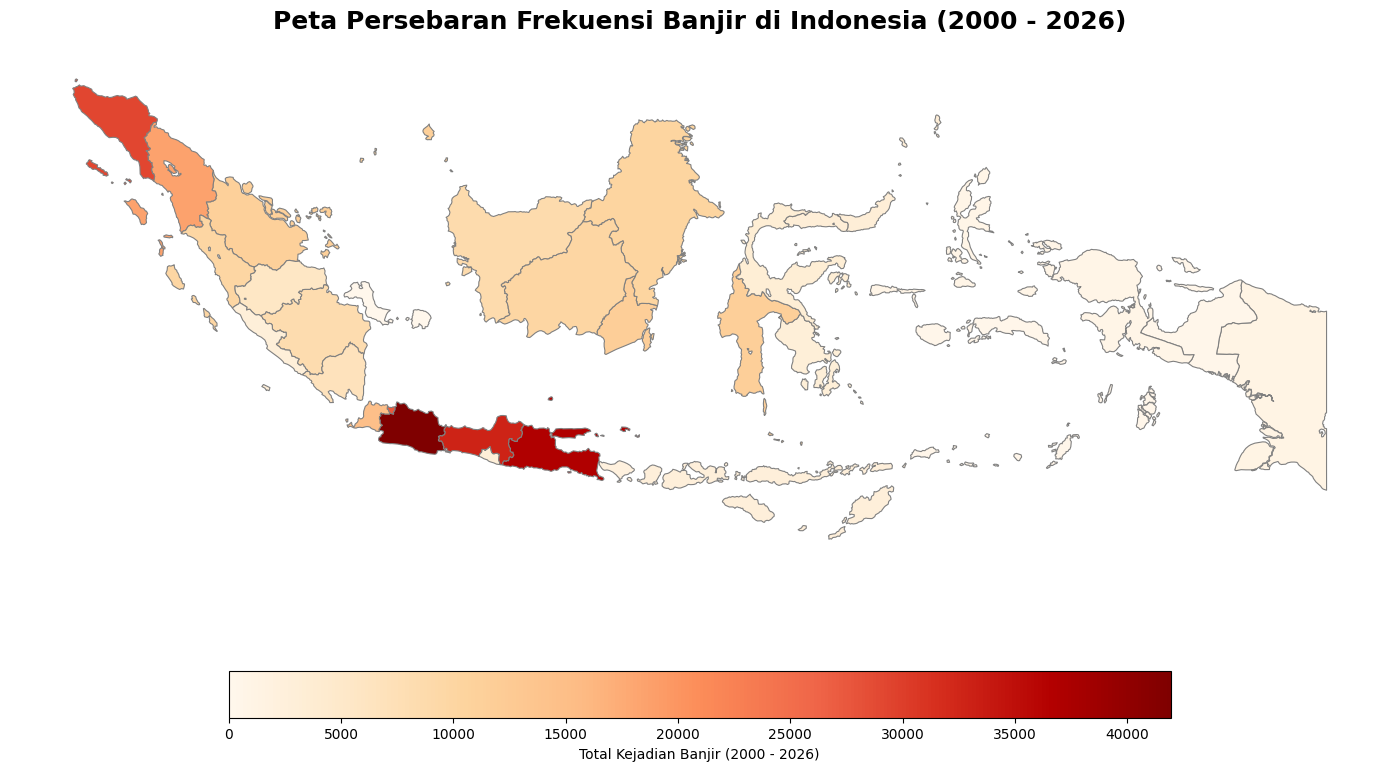


[INFO] Gambar peta berhasil disimpan ke folder 'processed' (peta_banjir_indonesia.png)!


In [15]:
import matplotlib.pyplot as plt

# 1. Menghitung total kejadian banjir untuk masing-masing provinsi secara keseluruhan (2000-2026)
# Kita gunakan variabel gdf_prov dan prov_map dari cell sebelumnya
frekuensi_prov = gdf_prov['Propinsi'].value_counts().reset_index()
frekuensi_prov.columns = ['Propinsi', 'total_kejadian']

# 2. Menggabungkan data frekuensi tadi kembali ke dalam data peta (GeoDataFrame)
map_data = prov_map.merge(frekuensi_prov, on='Propinsi', how='left')

# Jika ada provinsi yang tidak ada kejadian banjir, kita isi dengan angka 0
map_data['total_kejadian'] = map_data['total_kejadian'].fillna(0)

# ==========================================
# 3. VISUALISASI PETA (CHOROPLETH MAP)
# ==========================================
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# Membuat peta berdasarkan kolom 'total_kejadian'
# cmap='OrRd' akan memberikan gradasi warna dari Oranye ke Merah (cocok untuk kebencanaan)
map_data.plot(column='total_kejadian', 
              cmap='OrRd', 
              linewidth=0.8, 
              ax=ax, 
              edgecolor='0.5', # Warna garis batas provinsi (abu-abu)
              legend=True,
              legend_kwds={'label': "Total Kejadian Banjir (2000 - 2026)", 
                           'orientation': "horizontal",
                           'shrink': 0.6}) # Memperkecil ukuran bar legenda

# Pengaturan Judul dan Tampilan
ax.set_title('Peta Persebaran Frekuensi Banjir di Indonesia (2000 - 2026)', 
             fontsize=18, fontweight='bold', pad=20)

# Mematikan sumbu X dan Y agar terlihat bersih seperti peta sungguhan
ax.axis('off')

# Menyesuaikan layout agar rapi
fig.tight_layout()

# Menampilkan peta
plt.show()

# 4. (Opsional) Menyimpan Peta ke format gambar transparan tinggi resolusi (PNG) untuk dimasukkan ke Figma/Illustrator
fig.savefig('../data/processed/peta_banjir_indonesia.png', dpi=300, transparent=True)
print("\n[INFO] Gambar peta berhasil disimpan ke folder 'processed' (peta_banjir_indonesia.png)!")

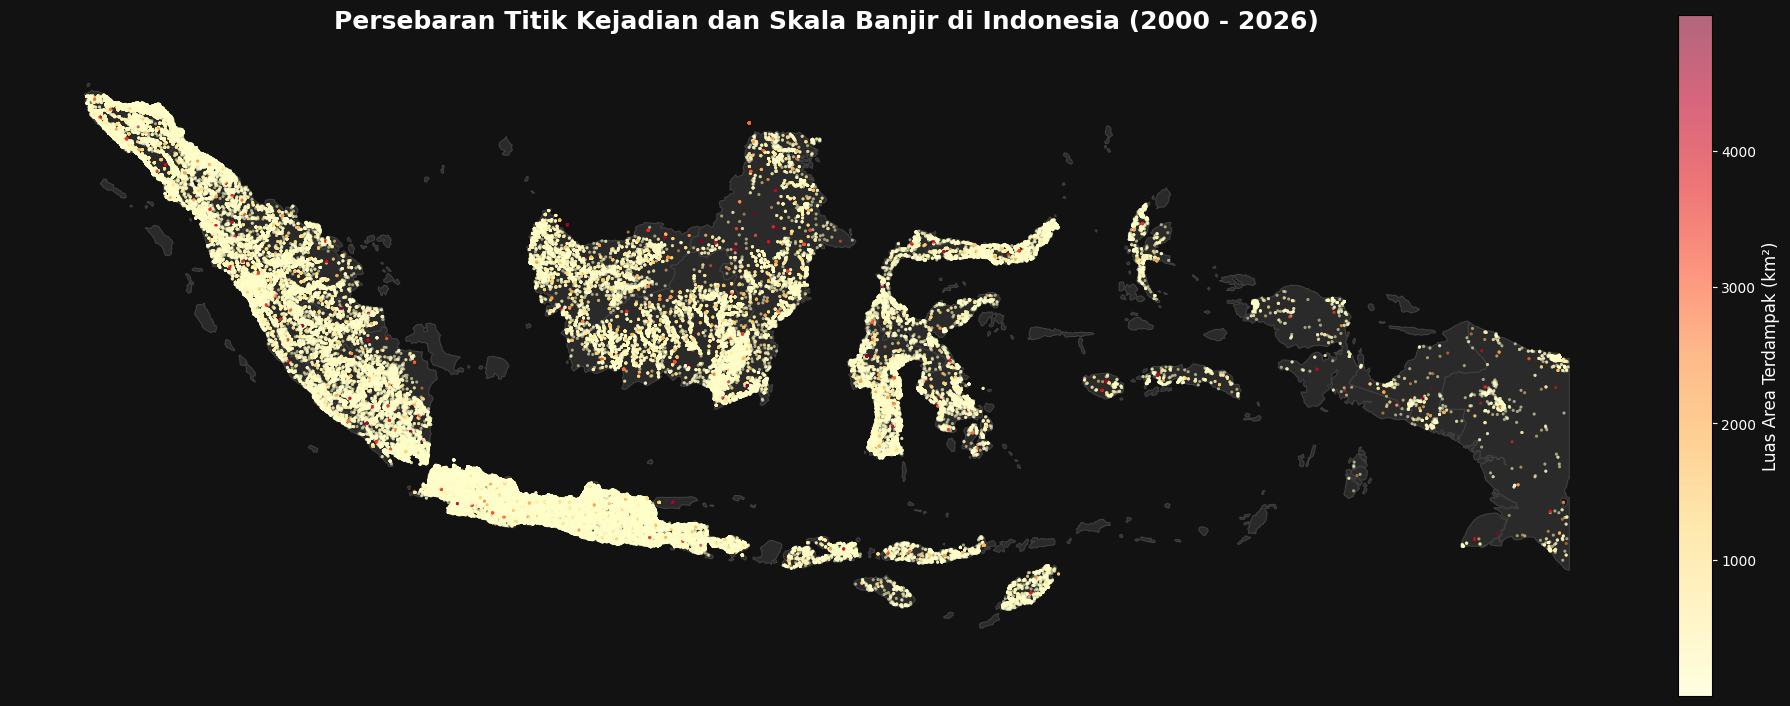


[INFO] Visualisasi Dot Map Dark Mode berhasil disimpan!


In [16]:
import matplotlib.pyplot as plt
import warnings

# Menonaktifkan peringatan sementara agar output bersih
warnings.filterwarnings('ignore')

# ==========================================
# VISUALISASI DOT MAP (DARK MODE)
# ==========================================

# 1. Membuat Kanvas dengan Background Gelap
fig, ax = plt.subplots(1, 1, figsize=(18, 8))
fig.patch.set_facecolor('#121212') # Warna background gambar (Hitam elegan)
ax.set_facecolor('#121212')        # Warna background peta

# 2. Menggambar Peta Dasar (Base Map) Indonesia
# Menggunakan warna abu-abu gelap untuk daratan agar titik warna lebih 'pop-out'
prov_map.plot(ax=ax, color='#2a2a2a', edgecolor='#404040', linewidth=0.8)

# 3. Menyiapkan Titik Pusat (Centroid) Banjir
# Karena data Groundsource mungkin berbentuk area/poligon, kita ubah jadi titik (dot)
titik_banjir = gdf_clean.copy()
titik_x = titik_banjir.geometry.centroid.x
titik_y = titik_banjir.geometry.centroid.y

# 4. Menggambar Titik (Scatter) dengan Gradasi Warna
# Parameter 'c' menentukan data apa yang jadi dasar warna (kita pakai area_km2)
# Parameter 'cmap' menentukan palet warnanya (YlOrRd = Yellow-Orange-Red)
scatter = ax.scatter(
    titik_x, 
    titik_y,
    c=titik_banjir['area_km2'], 
    cmap='YlOrRd',  # Ganti jadi 'turbo' atau 'plasma' jika ingin warna-warni pelangi
    s=5,            # Ukuran titik, dibuat kecil agar elegan
    alpha=0.6,      # Transparansi, agar area yang sering banjir makin terang karena menumpuk
    zorder=5,       # Memastikan titik digambar di atas peta
    edgecolors='none'
)

# 5. Styling Teks & Judul
ax.set_title('Persebaran Titik Kejadian dan Skala Banjir di Indonesia (2000 - 2026)', 
             fontsize=18, fontweight='bold', color='white', pad=20)
ax.axis('off') # Menghilangkan garis tepi sumbu X dan Y

# 6. Menambahkan Colorbar (Legenda Skala Warna)
cbar = plt.colorbar(scatter, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label('Luas Area Terdampak (km²)', color='white', fontsize=12)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white') # Mengubah warna angka skala jadi putih

fig.tight_layout()
plt.show()

# 7. (Opsional) Menyimpan Gambar untuk di-embed ke laporan/poster
fig.savefig('../data/processed/dot_map_banjir_darkmode.png', dpi=300, facecolor='#121212')
print("\n[INFO] Visualisasi Dot Map Dark Mode berhasil disimpan!")

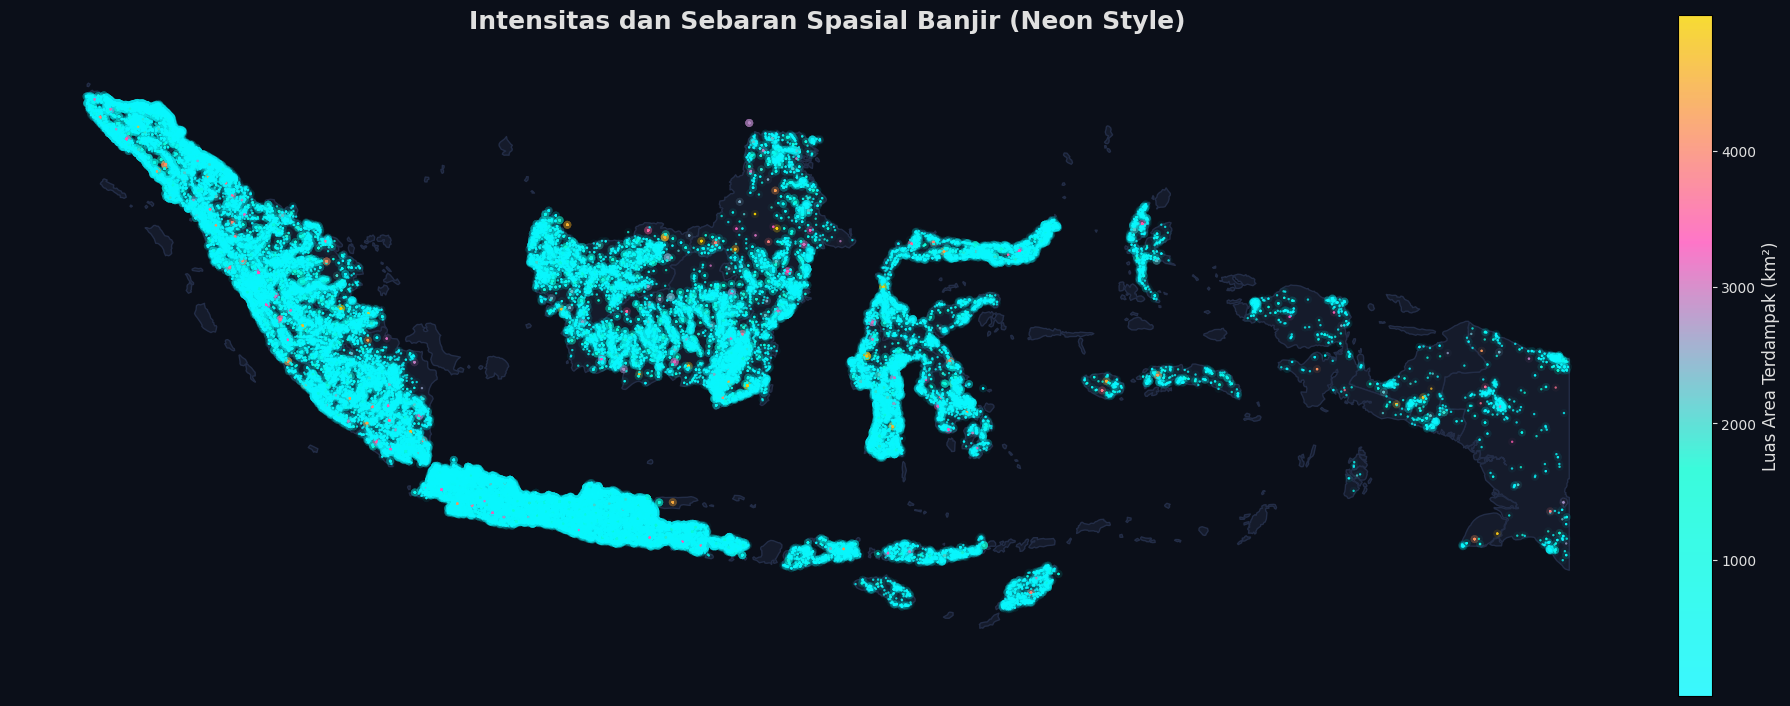


[INFO] Visualisasi Dot Map dengan warna Neon berhasil disimpan!


In [17]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# VISUALISASI DOT MAP (NEON / CYBERPUNK STYLE)
# ==========================================

# 1. Membuat Kanvas dengan Background Deep Navy/Black
fig, ax = plt.subplots(1, 1, figsize=(18, 8))
bg_color = '#0b0f19' # Warna background mirip referensi (biru sangat gelap)
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# 2. Menggambar Peta Dasar
# Warna daratan biru gelap/keabu-abuan agar menyatu dengan background dan menonjolkan titik
prov_map.plot(ax=ax, color='#151b2b', edgecolor='#232d47', linewidth=1)

# 3. Menyiapkan Titik Pusat
titik_banjir = gdf_clean.copy()
titik_x = titik_banjir.geometry.centroid.x
titik_y = titik_banjir.geometry.centroid.y

# 4. Membuat Custom Colormap (Cyan to Magenta/Pink mirip gambar referensi)
# Warna bergradasi dari Cyan terang -> Pink Neon -> Kuning (untuk area paling parah)
neon_colors = ['#08F7FE', '#09FBD3', '#FE53BB', '#F5D300']
neon_cmap = LinearSegmentedColormap.from_list('neon_cyberpunk', neon_colors)

# 5. Menggambar Titik dengan Trik "GLOW EFFECT"
# Layer 1: Cahaya Pendar (Glow) - Titik lebih besar, sangat transparan
ax.scatter(titik_x, titik_y, c=titik_banjir['area_km2'], cmap=neon_cmap, 
           s=35, alpha=0.04, zorder=4, edgecolors='none')

# Layer 2: Inti Titik (Core) - Titik lebih kecil, lebih solid
scatter = ax.scatter(titik_x, titik_y, c=titik_banjir['area_km2'], cmap=neon_cmap, 
                     s=3, alpha=0.8, zorder=5, edgecolors='none')

# 6. Styling Teks & Judul
ax.set_title('Intensitas dan Sebaran Spasial Banjir (Neon Style)', 
             fontsize=18, fontweight='bold', color='#E0E0E0', pad=20)
ax.axis('off') # Menghilangkan garis sumbu

# 7. Menambahkan Colorbar (Legenda Skala Warna)
cbar = plt.colorbar(scatter, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label('Luas Area Terdampak (km²)', color='#E0E0E0', fontsize=12)
cbar.ax.yaxis.set_tick_params(color='#E0E0E0')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='#E0E0E0') # Ubah teks jadi putih/abu terang

fig.tight_layout()
plt.show()

# 8. Menyimpan Gambar resolusi tinggi
fig.savefig('../data/processed/dot_map_banjir_neon.png', dpi=300, facecolor=bg_color)
print("\n[INFO] Visualisasi Dot Map dengan warna Neon berhasil disimpan!")

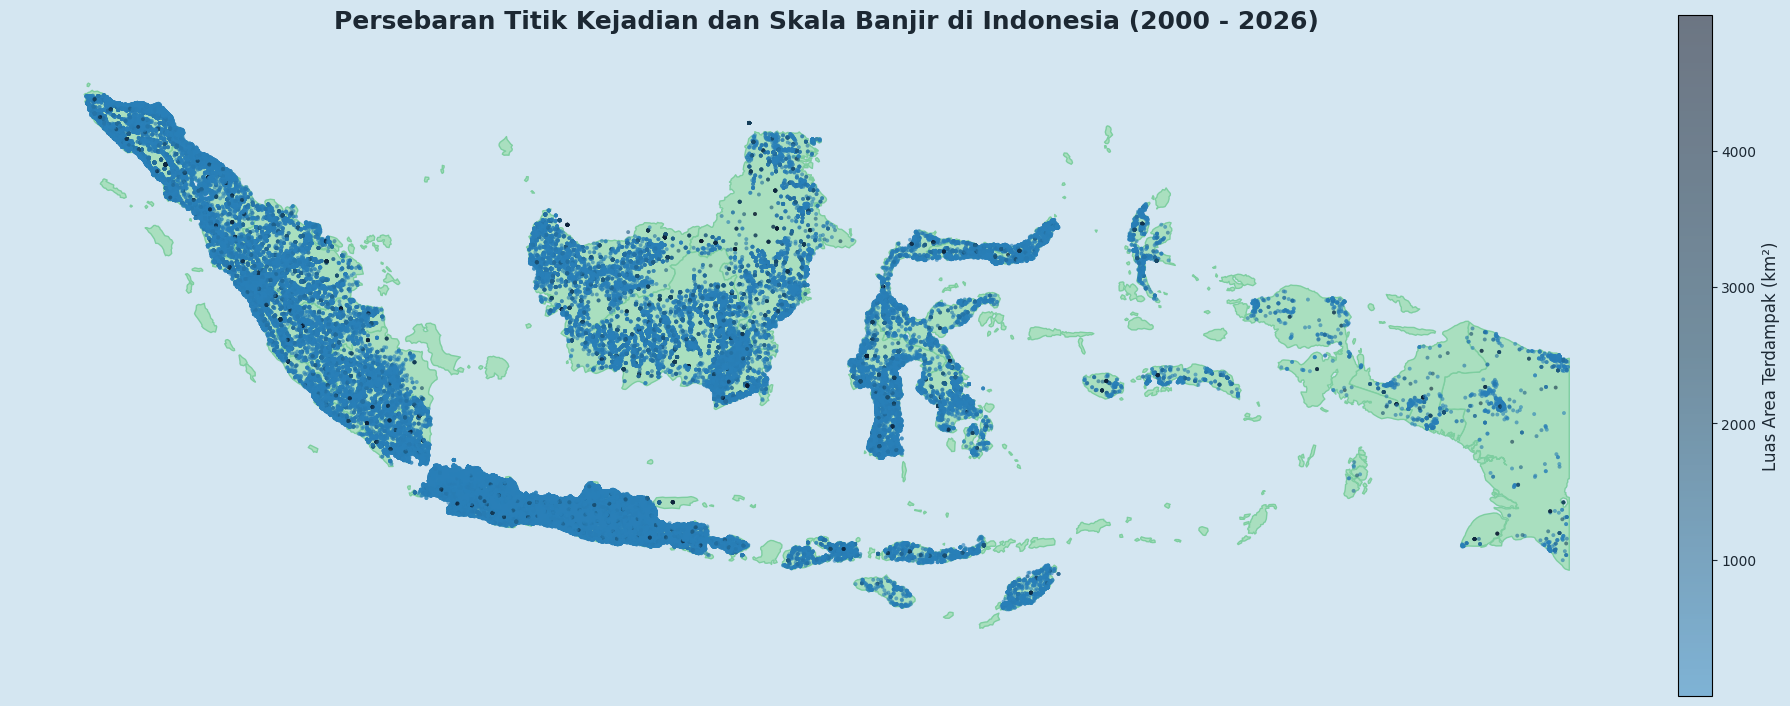


[INFO] Visualisasi Dot Map Tema Hijau-Biru berhasil disimpan!


In [18]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# VISUALISASI DOT MAP (CLASSIC GEO-MAP STYLE)
# ==========================================

# 1. Menyiapkan Skema Warna (Hex Codes)
warna_laut = '#D4E6F1'    # Biru muda (Light Blue)
warna_daratan = '#A9DFBF' # Hijau lembut (Soft Green)
warna_garis = '#7DCEA0'   # Hijau sedikit lebih tua untuk garis batas provinsi

# 2. Membuat Kanvas dengan Background Laut (Biru Muda)
fig, ax = plt.subplots(1, 1, figsize=(18, 8))
fig.patch.set_facecolor(warna_laut)
ax.set_facecolor(warna_laut)

# 3. Menggambar Peta Dasar (Daratan Hijau)
prov_map.plot(ax=ax, color=warna_daratan, edgecolor=warna_garis, linewidth=1)

# 4. Menyiapkan Titik Pusat
titik_banjir = gdf_clean.copy()
titik_x = titik_banjir.geometry.centroid.x
titik_y = titik_banjir.geometry.centroid.y

# 5. Membuat Custom Colormap untuk Titik (Biru ke Biru Tua/Navy)
# Agar tidak datar, titik yang areanya kecil berwarna biru standar, 
# sedangkan area yang sangat luas akan menjadi biru sangat tua (Navy)
blue_colors = ['#2980B9', '#154360', '#0B1A30']
blue_cmap = LinearSegmentedColormap.from_list('dark_blues', blue_colors)

# 6. Menggambar Titik Biru Tua
scatter = ax.scatter(
    titik_x, 
    titik_y,
    c=titik_banjir['area_km2'], 
    cmap=blue_cmap, 
    s=8,            # Ukuran titik sedikit diperbesar agar jelas di atas warna hijau
    alpha=0.6,      # Transparansi agar penumpukan titik di Jawa/Sumatera terlihat tebal
    zorder=5, 
    edgecolors='none'
)

# 7. Styling Teks & Judul
# Menggunakan warna teks gelap (#1C2833) agar terbaca jelas di atas biru muda
ax.set_title('Persebaran Titik Kejadian dan Skala Banjir di Indonesia (2000 - 2026)', 
             fontsize=18, fontweight='bold', color='#1C2833', pad=20)
ax.axis('off') # Menghilangkan garis tepi sumbu

# 8. Menambahkan Colorbar (Legenda Skala Warna)
cbar = plt.colorbar(scatter, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label('Luas Area Terdampak (km²)', color='#1C2833', fontsize=12)
cbar.ax.yaxis.set_tick_params(color='#1C2833')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='#1C2833') # Teks colorbar jadi gelap

fig.tight_layout()
plt.show()

# 9. Menyimpan Gambar
fig.savefig('../data/processed/dot_map_banjir_klasik.png', dpi=300, facecolor=warna_laut)
print("\n[INFO] Visualisasi Dot Map Tema Hijau-Biru berhasil disimpan!")

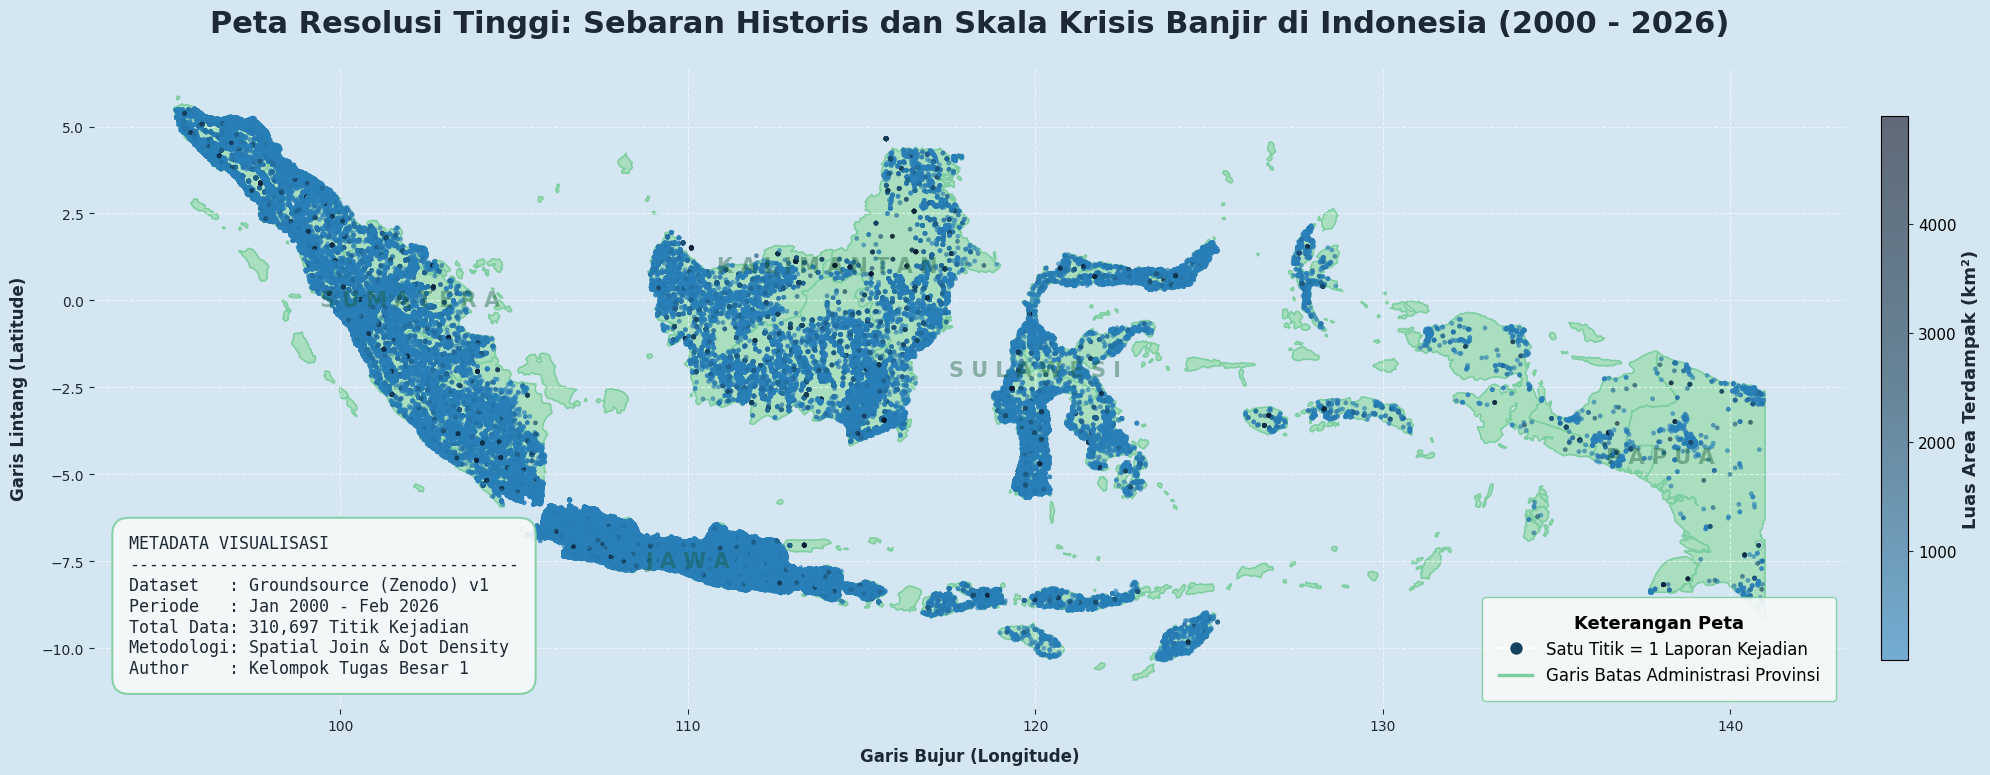


[INFO] Visualisasi Dot Map Super Detail berhasil disimpan ke file PNG!


In [21]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# VISUALISASI DOT MAP (CLASSIC GEO-MAP SUPER DETAIL)
# ==========================================

# 1. Menyiapkan Skema Warna
warna_laut = '#D4E6F1'    
warna_daratan = '#A9DFBF' 
warna_garis = '#7DCEA0'   

# 2. Membuat Kanvas (Ukuran diperbesar agar detail tidak pecah)
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
fig.patch.set_facecolor(warna_laut)
ax.set_facecolor(warna_laut)

# 3. Menggambar Peta Dasar
prov_map.plot(ax=ax, color=warna_daratan, edgecolor=warna_garis, linewidth=1.2, zorder=1)

# 4. Menyiapkan Data Titik
titik_banjir = gdf_clean.copy()
titik_x = titik_banjir.geometry.centroid.x
titik_y = titik_banjir.geometry.centroid.y

# 5. Colormap Biru Tua (Navy) untuk Skala Dampak
blue_colors = ['#2980B9', '#154360', '#0B1A30']
blue_cmap = LinearSegmentedColormap.from_list('dark_blues', blue_colors)

# 6. Scatter Plot Titik Banjir
scatter = ax.scatter(
    titik_x, titik_y,
    c=titik_banjir['area_km2'],
    cmap=blue_cmap,
    s=12,           # Sedikit diperbesar agar solid
    alpha=0.65,     
    zorder=5, 
    edgecolors='none'
)

# 7. Menambahkan Anotasi Nama Pulau Besar (Orientasi Spasial)
# Menambahkan spasi manual pada string sebagai pengganti letterspacing
pulau_labels = {
    'S U M A T E R A': (102.0, 0.0),
    'J A W A': (110.0, -7.5),
    'K A L I M A N T A N': (114.0, 1.0),
    'S U L A W E S I': (120.0, -2.0),
    'P A P U A': (138.0, -4.5)
}
for pulau, (x, y) in pulau_labels.items():
    # Menghapus argumen letterspacing yang menyebabkan error
    ax.text(x, y, pulau, fontsize=15, fontweight='bold', color='#145A32', 
            alpha=0.4, ha='center', va='center', zorder=6)

# 8. Menambahkan Grid Geografis (Garis Lintang & Bujur)
ax.grid(True, color='#FFFFFF', linestyle='--', linewidth=0.8, alpha=0.6, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(colors='#1C2833', labelsize=10)
ax.set_xlabel('Garis Bujur (Longitude)', color='#1C2833', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Garis Lintang (Latitude)', color='#1C2833', fontsize=12, fontweight='bold', labelpad=10)

# 9. Styling Judul Visualisasi
ax.set_title('Peta Resolusi Tinggi: Sebaran Historis dan Skala Krisis Banjir di Indonesia (2000 - 2026)', 
             fontsize=22, fontweight='bold', color='#1C2833', pad=25)

# 10. Menambahkan Colorbar (Legenda Skala Gradasi Warna)
cbar = plt.colorbar(scatter, ax=ax, fraction=0.015, pad=0.02)
cbar.set_label('Luas Area Terdampak (km²)', color='#1C2833', fontsize=13, fontweight='bold')
cbar.ax.yaxis.set_tick_params(color='#1C2833', labelsize=11)

# 11. Menambahkan KOTAK METADATA (Kiri Bawah)
info_text = (
    "METADATA VISUALISASI\n"
    "---------------------------------------\n"
    "Dataset   : Groundsource (Zenodo) v1\n"
    "Periode   : Jan 2000 - Feb 2026\n"
    f"Total Data: {len(titik_banjir):,} Titik Kejadian\n"
    "Metodologi: Spatial Join & Dot Density\n"
    "Author    : Kelompok Tugas Besar 1"
)
props = dict(boxstyle='round,pad=1', facecolor='#F8F9F9', alpha=0.9, edgecolor='#7DCEA0', linewidth=1.5)
ax.text(0.02, 0.05, info_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='bottom', bbox=props, color='#1C2833', fontfamily='monospace', zorder=10)

# 12. Menambahkan LEGENDA SIMBOL UTAMA (Kanan Bawah)
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Satu Titik = 1 Laporan Kejadian', 
           markerfacecolor='#154360', markersize=10),
    Line2D([0], [0], color=warna_garis, lw=2.5, label='Garis Batas Administrasi Provinsi')
]
ax.legend(handles=legend_elements, loc='lower right', title='Keterangan Peta',
          title_fontproperties={'weight':'bold', 'size': 13}, frameon=True, facecolor='#F8F9F9', 
          edgecolor='#7DCEA0', framealpha=0.9, fontsize=12, borderpad=1)

# Merapikan layout akhir
fig.tight_layout()
plt.show()

# 13. Menyimpan Gambar Resolusi Tinggi (400 DPI untuk kualitas cetak Poster)
fig.savefig('../data/processed/dot_map_banjir_klasik_super_detail.png', dpi=400, facecolor=warna_laut)
print("\n[INFO] Visualisasi Dot Map Super Detail berhasil disimpan ke file PNG!")